# Thesis data acquisition

This notebook creates only the univariate datasets used by the thesis point-forecast and future probabilistic experiments:

- quarterly real GDP for Argentina and the United States;
- monthly EMAE for Argentina;
- monthly US Coincident Economic Activity Index (ECAI) and unemployment rate;
- daily S&P 500 prices and log returns.

The separate Forte replication supplies the inflation experiment, so no CPI or OECD inflation data are downloaded here. The notebook also plots each series and performs a conservative outlier audit. The audit is descriptive: it does not alter the forecasting data.

Install missing acquisition dependencies in the active environment outside the notebook with `conda install -n timeseriesforecasting -c conda-forge requests certifi yfinance`.

In [1]:
from pathlib import Path
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import certifi
import requests
import yfinance as yf
from IPython.display import display
from statsmodels.tsa.seasonal import STL

SEED = 67
np.random.seed(SEED)

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / 'thesis').exists():
    REPO_ROOT = REPO_ROOT.parent
DATA_DIR = REPO_ROOT / 'thesis' / 'data'
DATA_DIR.mkdir(parents=True, exist_ok=True)

# Freeze the manual benchmark at the end of 2025: train <= 2023,
# validation = 2024, and test = 2025.
DATA_END = '2025-12-31'
YAHOO_END_EXCLUSIVE = '2026-01-01'
SP500_START = '2000-01-01'

# EMAE defaults to the CSV already used by the forecasting notebooks.
# Change to 'api' only when an explicit refresh is wanted.
EMAE_SOURCE = 'local'  # 'local' or 'api'
EMAE_LOCAL_PATH = DATA_DIR / 'emae-valores-anuales-indice-base-2004-mensual.csv'

SHOW_PLOTS = True
SAVE_FIGURES = True
FIGURE_FORMAT = 'jpg'
FIGURE_DIR = REPO_ROOT / 'thesis' / 'imgs' / 'data_wrangling'
if SAVE_FIGURES:
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)


## Export and audit helpers

In [2]:
def save_series(series, filename, target_name):
    """Save one numeric Series using the common manual-dataset schema."""
    clean = pd.to_numeric(series, errors='coerce').dropna().sort_index()
    clean.index = pd.to_datetime(clean.index)
    if clean.index.tz is not None:
        clean.index = clean.index.tz_convert(None)
    clean = clean.loc[~clean.index.duplicated(keep='last')]
    frame = clean.rename(target_name).rename_axis('indice_tiempo').reset_index()
    frame.to_csv(DATA_DIR / filename, index=False)
    return frame


def audit_frame(name, frame, target_columns, expected_frequency):
    dates = pd.to_datetime(frame['indice_tiempo'])
    return {
        'Dataset': name,
        'Expected frequency': expected_frequency,
        'Rows': len(frame),
        'Start': dates.min().date(),
        'End': dates.max().date(),
        'Duplicate dates': int(dates.duplicated().sum()),
        'Missing target values': int(frame[target_columns].isna().sum().sum()),
    }


## FRED macroeconomic series

The FRED key is read from `FRED_API_KEY`; it is never stored in the notebook. Argentina GDP uses the IMF real-GDP series (`NGDPRNSAXDCARQ`). US GDP uses the BEA non-seasonally-adjusted chained-dollar series (`ND000334Q`). The monthly US series are `USPHCI` and `UNRATE`.

In [3]:
fred_api_key = os.getenv('FRED_API_KEY')
if not fred_api_key:
    raise RuntimeError(
        'Set FRED_API_KEY in the timeseriesforecasting environment before running.'
    )
fred_specs = {
    'real_gdp_argentina': {
        'series_id': 'NGDPRNSAXDCARQ',
        'start': '1993-01-01',
        'filename': 'real_gdp_argentina_quarterly.csv',
        'target': 'real_gdp',
        'frequency': 'quarterly',
    },
    'real_gdp_us': {
        'series_id': 'ND000334Q',
        'start': '1947-01-01',
        'filename': 'real_gdp_us_quarterly.csv',
        'target': 'real_gdp',
        'frequency': 'quarterly',
    },
    'ecai_us': {
        'series_id': 'USPHCI',
        'start': '1979-01-01',
        'filename': 'ecai_us_monthly.csv',
        'target': 'ecai',
        'frequency': 'monthly',
    },
    'unemployment_us': {
        'series_id': 'UNRATE',
        'start': '1948-01-01',
        'filename': 'unemployment_us_monthly.csv',
        'target': 'unemployment_rate',
        'frequency': 'monthly',
    },
}

def fetch_fred_series(series_id, observation_start, observation_end):
    """Fetch one FRED series through verified JSON HTTPS."""
    response = requests.get(
        'https://api.stlouisfed.org/fred/series/observations',
        params={
            'series_id': series_id,
            'api_key': fred_api_key,
            'file_type': 'json',
            'observation_start': observation_start,
            'observation_end': observation_end,
            'sort_order': 'asc',
        },
        timeout=60,
        verify=certifi.where(),
    )
    response.raise_for_status()
    observations = pd.DataFrame(response.json()['observations'])
    if observations.empty:
        raise ValueError(f'FRED returned no observations for {series_id}')
    observations['date'] = pd.to_datetime(observations['date'])
    observations['value'] = pd.to_numeric(
        observations['value'].replace('.', np.nan), errors='coerce'
    )
    return observations.set_index('date')['value'].dropna()


exported = {}
audit_rows = []
for dataset_name, spec in fred_specs.items():
    series = fetch_fred_series(
        spec['series_id'], spec['start'], DATA_END
    )
    frame = save_series(series, spec['filename'], spec['target'])
    exported[dataset_name] = frame
    audit_rows.append(
        audit_frame(dataset_name, frame, [spec['target']], spec['frequency'])
    )


## Argentina EMAE: local file by default, optional API refresh

The default `EMAE_SOURCE='local'` reads and plots the CSV already used by the forecasting notebooks. To provide a manually downloaded replacement, copy it to `thesis/data/emae-valores-anuales-indice-base-2004-mensual.csv` or point `EMAE_LOCAL_PATH` at another CSV with `indice_tiempo` and `emae_original` columns. Set `EMAE_SOURCE='api'` only for an explicit refresh from the official series API (`143.3_NO_PR_2004_A_21`).

In [4]:
if EMAE_SOURCE not in {'local', 'api'}:
    raise ValueError("EMAE_SOURCE must be 'local' or 'api'")

if EMAE_SOURCE == 'local':
    if not EMAE_LOCAL_PATH.exists():
        raise FileNotFoundError(
            f'EMAE CSV not found at {EMAE_LOCAL_PATH}. Upload/copy the file '
            'there or change EMAE_LOCAL_PATH.'
        )
    emae = pd.read_csv(EMAE_LOCAL_PATH)
else:
    emae_response = requests.get(
        'https://apis.datos.gob.ar/series/api/series',
        params={
            'ids': '143.3_NO_PR_2004_A_21',
            'start_date': '1993-01-01',
            'end_date': DATA_END,
            'limit': 1000,
            'sort': 'asc',
            'metadata': 'simple',
        },
        timeout=60,
        verify=certifi.where(),
    )
    emae_response.raise_for_status()
    emae_payload = emae_response.json()
    emae = pd.DataFrame(
        emae_payload['data'], columns=['indice_tiempo', 'emae_original']
    )

required_emae_columns = {'indice_tiempo', 'emae_original'}
missing_emae_columns = required_emae_columns.difference(emae.columns)
if missing_emae_columns:
    raise ValueError(f'EMAE file is missing columns: {sorted(missing_emae_columns)}')
emae['indice_tiempo'] = pd.to_datetime(emae['indice_tiempo'])
emae['emae_original'] = pd.to_numeric(emae['emae_original'], errors='coerce')
emae = emae.dropna(subset=['emae_original']).sort_values('indice_tiempo')
emae = emae.drop_duplicates('indice_tiempo', keep='last').reset_index(drop=True)
if EMAE_SOURCE == 'api':
    emae.to_csv(
        DATA_DIR / 'emae-valores-anuales-indice-base-2004-mensual.csv', index=False
    )
exported['emae'] = emae
audit_rows.append(audit_frame('emae', emae, ['emae_original'], 'monthly'))


## Financial series

The S&P 500 history starts in 2000 rather than 1927. This still retains roughly 6,500 trading observations—including the dot-com decline, global financial crisis, COVID-19 shock, and subsequent regimes—without imposing almost a century of repeated DL fitting. The file preserves both closing levels and log returns. It is excluded from point-forecast batch runs; its calibration and test chronology belongs in a separate probabilistic notebook.

In [5]:
def yahoo_close(ticker, start):
    history = yf.download(
        ticker,
        start=start,
        end=YAHOO_END_EXCLUSIVE,
        auto_adjust=False,
        progress=False,
    )
    if history.empty:
        raise RuntimeError(f'Yahoo Finance returned no observations for {ticker}')
    close = history['Close']
    if isinstance(close, pd.DataFrame):
        close = close.iloc[:, 0]
    close.index = pd.to_datetime(close.index)
    if close.index.tz is not None:
        close.index = close.index.tz_convert(None)
    return pd.to_numeric(close, errors='coerce').dropna().sort_index()


sp500_close = yahoo_close('^GSPC', SP500_START)
sp500 = pd.DataFrame({
    'close': sp500_close,
    'log_return': np.log(sp500_close).diff(),
}).dropna().rename_axis('indice_tiempo').reset_index()
sp500.to_csv(DATA_DIR / 'sp500_daily.csv', index=False)

exported['sp500_returns'] = sp500
audit_rows.append(
    audit_frame('sp500_returns', sp500, ['log_return'], 'trading day')
)


## Export audit

The audit is saved beside the datasets. Missing calendar dates are not treated as missing observations for business-day financial series because weekends and market holidays are outside their sampling calendar.

In [6]:
data_audit = (
    pd.DataFrame(audit_rows)
    .drop_duplicates(subset='Dataset', keep='last')
    .sort_values('Dataset')
    .reset_index(drop=True)
)
data_audit.to_csv(DATA_DIR / 'manual_data_audit.csv', index=False)
display(data_audit)

for dataset_name, frame in exported.items():
    print(f'\n{dataset_name}')
    display(frame.head(2))
    display(frame.tail(2))


,Dataset,Expected frequency,Rows,Start,End,Duplicate dates,Missing target values
0,ecai_us,monthly,564,1979-01-01,2025-12-01,0,0
1,emae,monthly,263,2004-01-01,2025-11-01,0,0
2,real_gdp_argentina,quarterly,88,2004-01-01,2025-10-01,0,0
3,real_gdp_us,quarterly,96,2002-01-01,2025-10-01,0,0
4,sp500_returns,trading day,6538,2000-01-04,2025-12-31,0,0
5,unemployment_us,monthly,935,1948-01-01,2025-12-01,0,0



real_gdp_argentina


,indice_tiempo,real_gdp
0,2004-01-01,115092.4
1,2004-04-01,128598.9


,indice_tiempo,real_gdp
86,2025-07-01,184283.8
87,2025-10-01,183800.5



real_gdp_us


...

,indice_tiempo,emae_original,emae_desestacionalizada,emae_tendencia_ciclo,emae_original_via,emae_desestacionalizada_vm,emae_tendencia_ciclo_vm
0,2004-01-01,92.627506,98.478317,96.063973,NaN,NaN,NaN
1,2004-02-01,90.186179,98.196605,96.660085,NaN,-0.002861,0.006205


,indice_tiempo,emae_original,emae_desestacionalizada,emae_tendencia_ciclo,emae_original_via,emae_desestacionalizada_vm,emae_tendencia_ciclo_vm
261,2025-10-01,152.770485,152.754477,152.102529,0.032271,-0.003941,-0.000367
262,2025-11-01,147.607990,152.371412,152.046115,-0.003116,-0.002508,-0.000371



sp500_returns


,indice_tiempo,close,log_return
0,2000-01-04,1399.420044,-0.039099
1,2000-01-05,1402.109985,0.001920


,indice_tiempo,close,log_return
6536,2025-12-30,6896.240234,-0.001377
6537,2025-12-31,6845.500000,-0.007385


## Series overview plots

All five macroeconomic series and both S&P 500 views are collected in one figure. The macro panels mark the frozen 2024 validation and 2025 test periods. The financial panels instead mark the 2023 selection, 2024 conformal-calibration, and 2025 test periods.

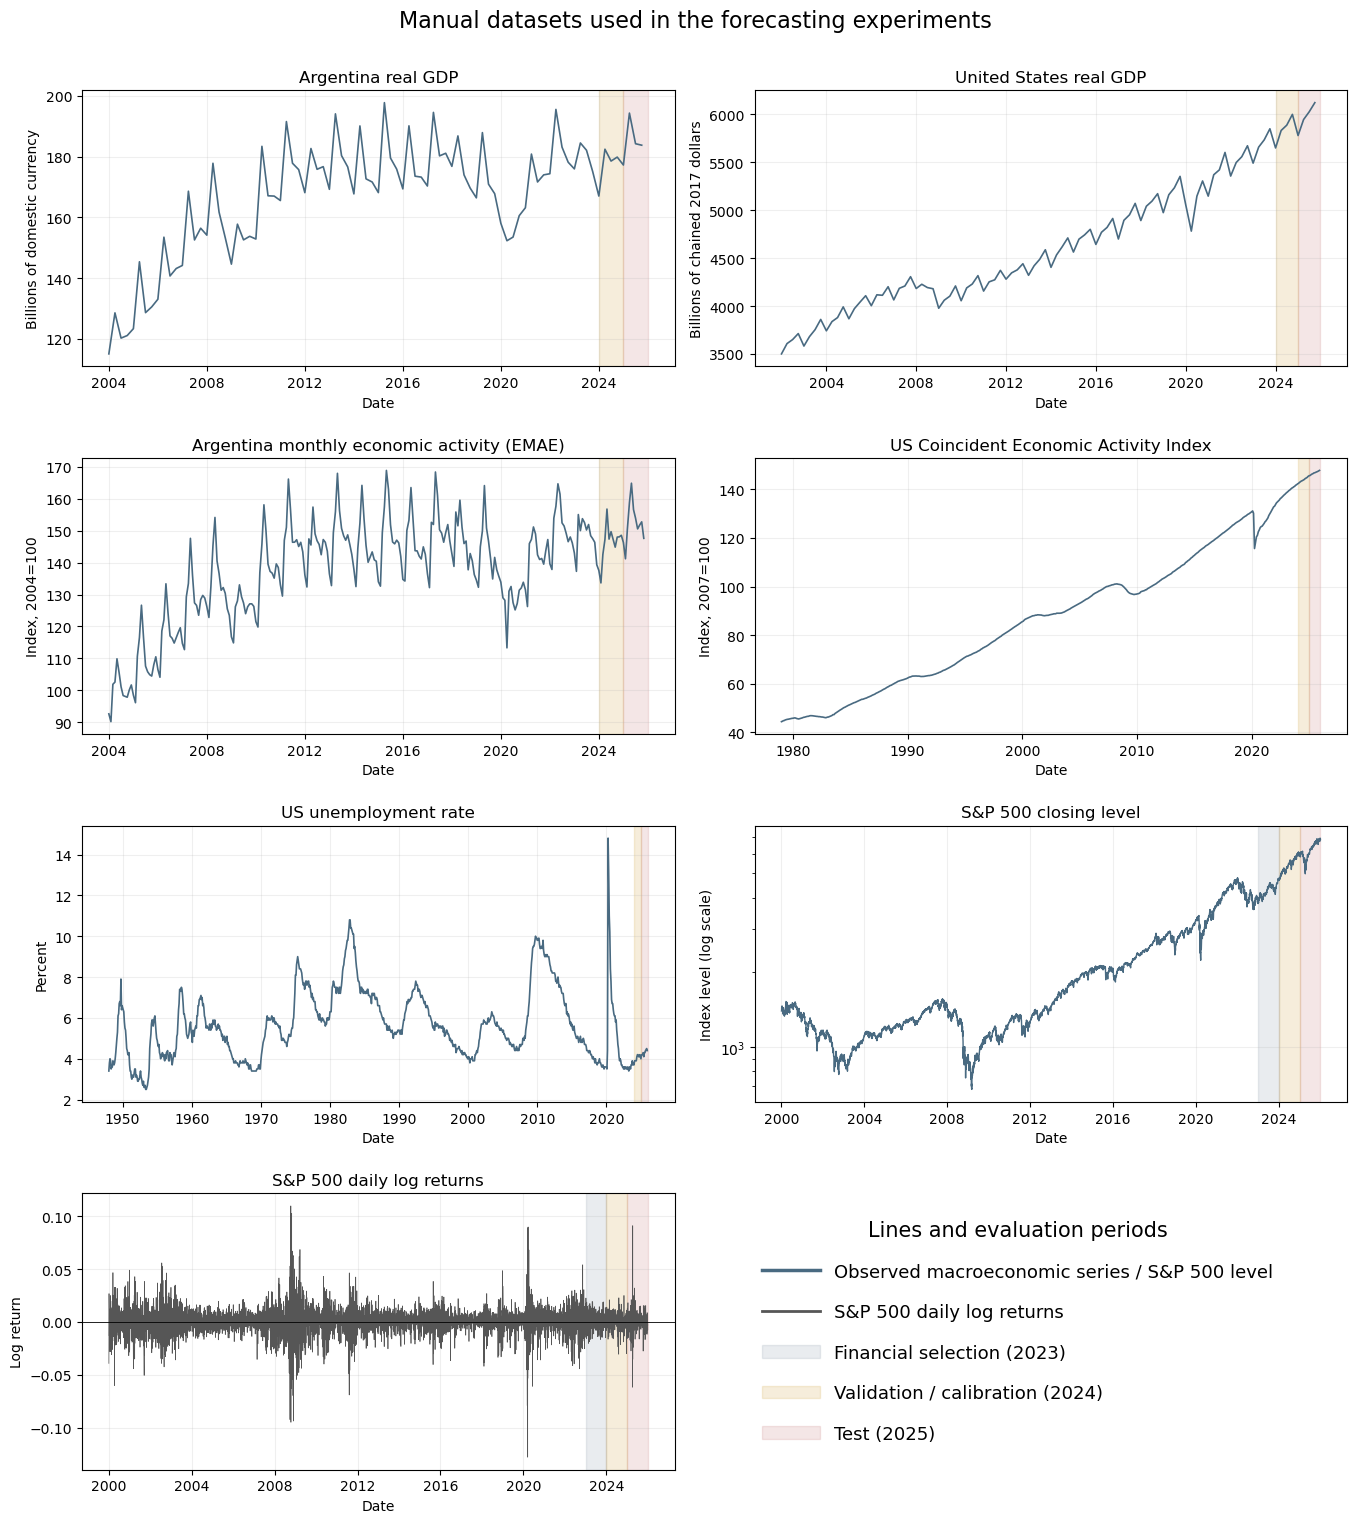

In [7]:
manual_plot_specs = [
    ('real_gdp_argentina', 'real_gdp', 'Argentina real GDP',
     'Billions of domestic currency'),
    ('real_gdp_us', 'real_gdp', 'United States real GDP',
     'Billions of chained 2017 dollars'),
    ('emae', 'emae_original', 'Argentina monthly economic activity (EMAE)',
     'Index, 2004=100'),
    ('ecai_us', 'ecai', 'US Coincident Economic Activity Index',
     'Index, 2007=100'),
    ('unemployment_us', 'unemployment_rate', 'US unemployment rate',
     'Percent'),
]
fig, axes = plt.subplots(4, 2, figsize=(14, 15.5))
axes = axes.flatten()
for axis, (dataset_name, value_column, title, ylabel) in zip(
    axes, manual_plot_specs
):
    frame = exported[dataset_name]
    dates = pd.to_datetime(frame['indice_tiempo'])
    values = pd.to_numeric(frame[value_column], errors='coerce')
    if dataset_name == 'real_gdp_argentina':
        values = values / 1_000.0
    axis.plot(dates, values, color='#496a81', linewidth=1.2)
    axis.axvspan(
        pd.Timestamp('2024-01-01'), pd.Timestamp('2024-12-31'),
        color='#d6a84b', alpha=0.20,
    )
    axis.axvspan(
        pd.Timestamp('2025-01-01'), pd.Timestamp('2025-12-31'),
        color='#b95d5d', alpha=0.15,
    )
    axis.set(title=title, xlabel='Date', ylabel=ylabel)
    axis.grid(alpha=0.20)

sp500_plot = exported['sp500_returns'].copy()
sp500_dates = pd.to_datetime(sp500_plot['indice_tiempo'])
financial_axes = axes[5:7]
financial_axes[0].plot(
    sp500_dates, sp500_plot['close'], color='#496a81', linewidth=1.0,
)
financial_axes[0].set(
    title='S&P 500 closing level', xlabel='Date', ylabel='Index level (log scale)',
)
financial_axes[0].set_yscale('log')
financial_axes[1].plot(
    sp500_dates, sp500_plot['log_return'],
    color='#565656', linewidth=0.50,
)
financial_axes[1].axhline(0, color='black', linewidth=0.6)
financial_axes[1].set(
    title='S&P 500 daily log returns', xlabel='Date', ylabel='Log return',
)
for axis in financial_axes:
    axis.axvspan(
        pd.Timestamp('2023-01-01'), pd.Timestamp('2023-12-31'),
        color='#788b9d', alpha=0.16,
    )
    axis.axvspan(
        pd.Timestamp('2024-01-01'), pd.Timestamp('2024-12-31'),
        color='#d6a84b', alpha=0.20,
    )
    axis.axvspan(
        pd.Timestamp('2025-01-01'), pd.Timestamp('2025-12-31'),
        color='#b95d5d', alpha=0.15,
    )
    axis.grid(alpha=0.20)
legend_axis = axes[7]
legend_axis.axis('off')
legend_handles = [
    plt.Line2D([0], [0], color='#496a81', linewidth=2.5,
               label='Observed macroeconomic series / S&P 500 level'),
    plt.Line2D([0], [0], color='#565656', linewidth=2.0,
               label='S&P 500 daily log returns'),
    plt.Rectangle((0, 0), 1, 1, color='#788b9d', alpha=0.16,
                  label='Financial selection (2023)'),
    plt.Rectangle((0, 0), 1, 1, color='#d6a84b', alpha=0.20,
                  label='Validation / calibration (2024)'),
    plt.Rectangle((0, 0), 1, 1, color='#b95d5d', alpha=0.15,
                  label='Test (2025)'),
]
legend_axis.legend(
    handles=legend_handles,
    loc='center left',
    frameon=False,
    fontsize=13,
    title='Lines and evaluation periods',
    title_fontsize=15,
    handlelength=3.2,
    labelspacing=1.25,
    borderaxespad=0.0,
)
fig.suptitle('Manual datasets used in the forecasting experiments', fontsize=16)
fig.tight_layout(rect=(0, 0, 1, 0.975), h_pad=2.0)
if SAVE_FIGURES:
    fig.savefig(
        FIGURE_DIR / f'data_wrangling_all_series.{FIGURE_FORMAT}',
        dpi=600, bbox_inches='tight',
    )
if SHOW_PLOTS:
    plt.show()
else:
    plt.close(fig)


## Outlier diagnostics

Outliers are diagnosed on residuals rather than on raw levels. A raw threshold can mistake a trend or recurring seasonal peak for an anomaly, so the monthly and quarterly macroeconomic series first undergo robust STL decomposition. Daily S&P 500 returns are already changes around a near-zero center and are median-centered directly. A conservative three-IQR rule then marks unusually large residuals.

This is an audit, not an automatic cleaning step. Flagged observations can represent genuine recessions, crises, or measurement changes and are retained in every exported dataset. The diagnostic is also independent of `AutoStationaryTransformer`, because that representation is not used by every forecasting model.


,Dataset,Diagnostic representation,IQR multiple,Training end,Observations,Flagged observations,Flagged percent
0,real_gdp_argentina,Robust STL residuals (period=4),1.5,2023-12-31,80,6,7.500000
1,real_gdp_us,Robust STL residuals (period=4),1.5,2023-12-31,88,16,18.181818
2,emae,Robust STL residuals (period=12),1.5,2023-12-31,240,50,20.833333
3,ecai_us,Robust STL residuals (period=12),1.5,2023-12-31,540,105,19.444444
4,unemployment_us,Robust STL residuals (period=12),1.5,2023-12-31,912,133,14.583333
5,sp500_returns,Median-centered residuals,1.5,2022-12-31,5786,421,7.276184


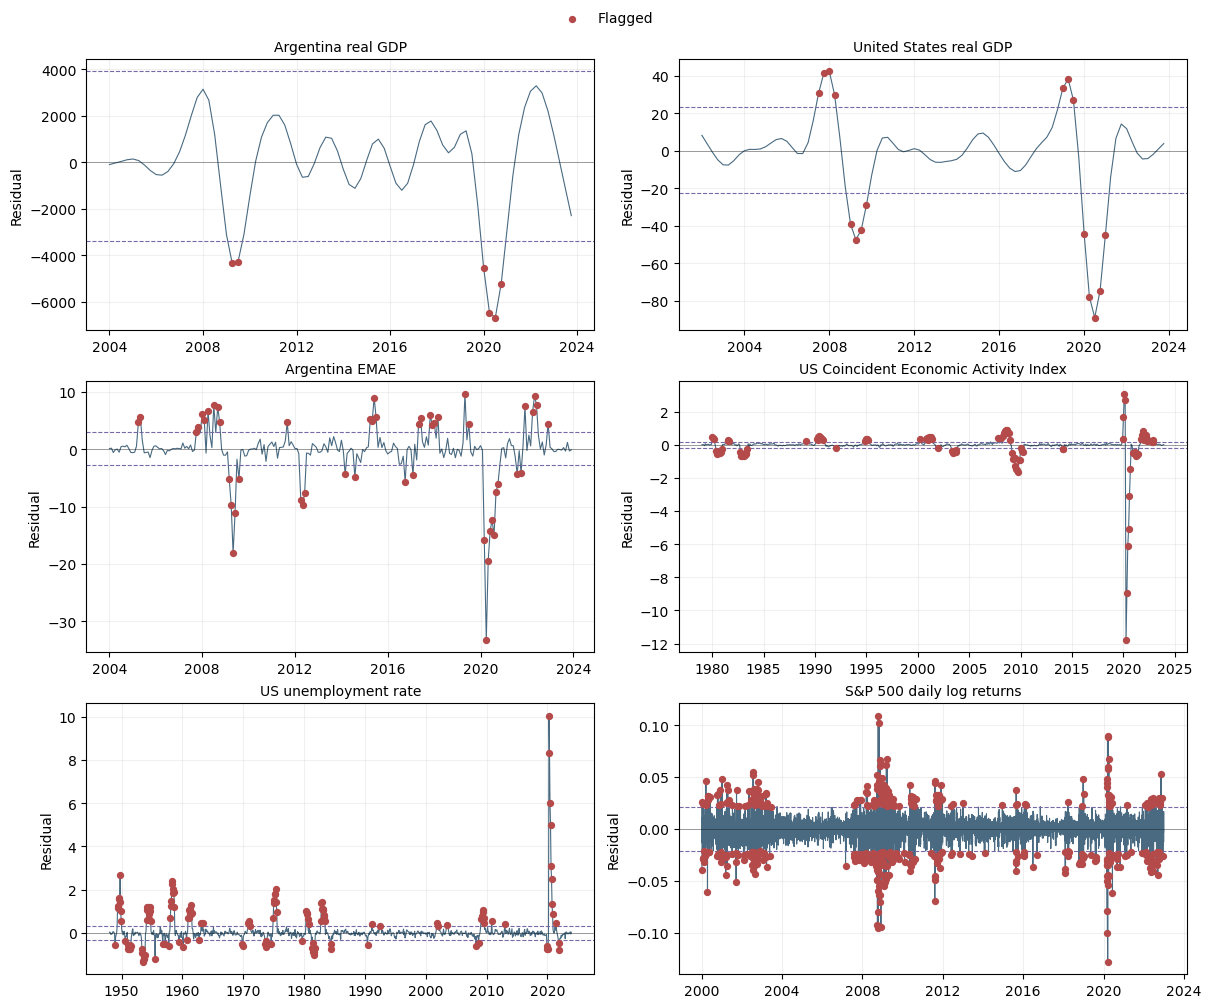

In [8]:
OUTLIER_IQR_MULTIPLE = 1.5
outlier_specs = {
    'real_gdp_argentina': ('real_gdp', 4, 'Argentina real GDP', '2023-12-31'),
    'real_gdp_us': ('real_gdp', 4, 'United States real GDP', '2023-12-31'),
    'emae': ('emae_original', 12, 'Argentina EMAE', '2023-12-31'),
    'ecai_us': ('ecai', 12, 'US Coincident Economic Activity Index', '2023-12-31'),
    'unemployment_us': ('unemployment_rate', 12, 'US unemployment rate', '2023-12-31'),
    'sp500_returns': ('log_return', None, 'S&P 500 daily log returns', '2022-12-31'),
}


def residual_iqr_outliers(frame, value_column, seasonal_period=None):
    dates = pd.to_datetime(frame['indice_tiempo'])
    values = pd.Series(
        pd.to_numeric(frame[value_column], errors='coerce').to_numpy(),
        index=dates,
        name=value_column,
    ).dropna().sort_index()
    if seasonal_period is None:
        residuals = values - values.median()
        decomposition = 'Median-centered residuals'
    else:
        if len(values) < 2 * seasonal_period + 1:
            raise ValueError(
                f'{value_column} needs at least two seasonal cycles for STL'
            )
        stl = STL(
            values, period=int(seasonal_period), robust=True,
            seasonal=7 if seasonal_period >= 7 else 3,
        ).fit()
        residuals = stl.resid
        decomposition = f'Robust STL residuals (period={seasonal_period})'

    q1, q3 = residuals.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - OUTLIER_IQR_MULTIPLE * iqr
    upper = q3 + OUTLIER_IQR_MULTIPLE * iqr
    flagged = (residuals < lower) | (residuals > upper)
    return residuals, flagged, lower, upper, decomposition


outlier_rows = []
outlier_results = {}
for dataset_name, (value_column, period, title, training_end) in outlier_specs.items():
    diagnostic_frame = exported[dataset_name].loc[
        pd.to_datetime(exported[dataset_name]['indice_tiempo']) <= pd.Timestamp(training_end)
    ]
    residuals, flagged, lower, upper, method = residual_iqr_outliers(
        diagnostic_frame, value_column, period
    )
    outlier_results[dataset_name] = (residuals, flagged, lower, upper, title)
    outlier_rows.append({
        'Dataset': dataset_name,
        'Diagnostic representation': method,
        'IQR multiple': OUTLIER_IQR_MULTIPLE,
        'Training end': training_end,
        'Observations': len(residuals),
        'Flagged observations': int(flagged.sum()),
        'Flagged percent': 100 * flagged.mean(),
    })

outlier_audit = pd.DataFrame(outlier_rows)
outlier_audit.to_csv(DATA_DIR / 'manual_outlier_audit.csv', index=False)
display(outlier_audit)

fig, axes = plt.subplots(3, 2, figsize=(12, 10), constrained_layout=True)
for axis, (dataset_name, result) in zip(axes.flat, outlier_results.items()):
    residuals, flagged, lower, upper, title = result
    axis.plot(residuals.index, residuals, color='#496a81', linewidth=0.8)
    axis.scatter(
        residuals.index[flagged], residuals.loc[flagged],
        color='#b54a4a', s=18, zorder=3, label='Flagged',
    )
    axis.axhline(lower, color='#7868a6', linestyle='--', linewidth=0.8)
    axis.axhline(upper, color='#7868a6', linestyle='--', linewidth=0.8)
    axis.axhline(0, color='black', linewidth=0.5, alpha=0.5)
    axis.set_title(title, fontsize=10)
    axis.set_ylabel('Residual')
    axis.grid(alpha=0.18)
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='outside upper center', frameon=False)
if SAVE_FIGURES:
    fig.savefig(
        FIGURE_DIR / f'data_wrangling_outlier_diagnostics.{FIGURE_FORMAT}',
        dpi=300, bbox_inches='tight',
    )
if SHOW_PLOTS:
    plt.show()
else:
    plt.close(fig)
